In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.environ["MBTA_API_KEY"] = "9ee5b2c61a704f62b1a67ed57fd9e184"

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

# Update these paths to wherever your CSVs are in Google Drive
PROJECT_ROOT = Path("/content/drive/MyDrive/CS506 Project")
MBTA_FINAL = PROJECT_ROOT / "mbta_final.csv"
SURVEY_2024 = PROJECT_ROOT / "MBTA_2024_System-Wide_Passenger_Survey.csv"

MBTA_API_KEY = os.environ.get("MBTA_API_KEY", "")
TARGET_ROUTE_IDS = {"28", "23", "111", "15"}
SAMPLE_N_ROWS = 500_000

print("MBTA final exists:", MBTA_FINAL.exists(), MBTA_FINAL)
print("Survey exists:", SURVEY_2024.exists(), SURVEY_2024)
print("API key loaded:", bool(MBTA_API_KEY))

MBTA final exists: True /content/drive/MyDrive/CS506 Project/mbta_final.csv
Survey exists: True /content/drive/MyDrive/CS506 Project/MBTA_2024_System-Wide_Passenger_Survey.csv
API key loaded: True


## 2. Peek at `mbta_final.csv` (schema + sample)

Adjust `SAMPLE_N_ROWS` or use chunked aggregation below for full-dataset statistics.

In [ ]:
cols = pd.read_csv(MBTA_FINAL, nrows=0).columns.tolist()
print("Columns (", len(cols), "):", cols)

df_sample = pd.read_csv(MBTA_FINAL, nrows=SAMPLE_N_ROWS, low_memory=False)
df_sample["route_id_str"] = df_sample["route_id"].astype(str).str.strip()
df_sample.shape

Columns ( 17 ): ['service_date', 'route_id', 'direction_id', 'half_trip_id', 'stop_id', 'time_point_id', 'time_point_order', 'point_type', 'standard_type', 'scheduled', 'actual', 'year', 'month', 'day', 'neighborhood', 'stop_name', 'municipality']


(500000, 18)

In [ ]:
df_sample.head(10)

,service_date,route_id,direction_id,half_trip_id,stop_id,time_point_id,time_point_order,point_type,standard_type,scheduled,actual,year,month,day,neighborhood,stop_name,municipality,route_id_str
0,2022-01-01,01,Inbound,54137355.0,110,hhgat,1.0,Startpoint,Schedule,1900-01-01 06:05:00.000,1900-01-01 06:24:56.000,2022,1,1,Unknown,Unknown,Unknown,01
1,2022-01-01,01,Inbound,54137355.0,67,maput,2.0,Midpoint,Schedule,1900-01-01 06:09:00.000,1900-01-01 06:27:46.000,2022,1,1,Unknown,Unknown,Unknown,01
2,2022-01-01,01,Inbound,54137355.0,72,cntsq,3.0,Midpoint,Schedule,1900-01-01 06:12:00.000,1900-01-01 06:32:16.000,2022,1,1,Unknown,Unknown,Unknown,01
3,2022-01-01,01,Inbound,54137355.0,75,mit,4.0,Midpoint,Schedule,1900-01-01 06:15:00.000,1900-01-01 06:35:03.000,2022,1,1,Unknown,Unknown,Unknown,01
4,2022-01-01,01,Inbound,54137355.0,79,hynes,5.0,Midpoint,Schedule,1900-01-01 06:19:00.000,1900-01-01 06:38:10.000,2022,1,1,Fenway,Massachusetts Ave @ Newbury St,Boston,01
5,2022-01-01,01,Inbound,54137355.0,187,masta,6.0,Midpoint,Schedule,1900-01-01 06:21:00.000,1900-01-01 06:42:40.000,2022,1,1,Roxbury,Massachusetts Ave @ Massachusetts Ave Station,Boston,01
6,2022-01-01,01,Inbound,54137355.0,59,Wasma,7.0,Midpoint,Schedule,1900-01-01 06:25:00.000,1900-01-01 06:45:39.000,2022,1,1,Roxbury,Massachusetts Ave @ Washington St,Boston,01
7,2022-01-01,01,Inbound,54137203.0,110,hhgat,1.0,Startpoint,Headway,1900-01-01 06:25:00.000,1900-01-01 06:25:53.000,2022,1,1,Unknown,Unknown,Unknown,01
8,2022-01-01,01,Inbound,54137203.0,67,maput,2.0,Midpoint,Headway,1900-01-01 06:29:00.000,1900-01-01 06:27:52.000,2022,1,1,Unknown,Unknown,Unknown,01
9,2022-01-01,01,Inbound,54137355.0,62,Melwa,8.0,Midpoint,Schedule,1900-01-01 06:29:00.000,1900-01-01 06:49:47.000,2022,1,1,Roxbury,Washington St @ Williams St,Boston,01


In [ ]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   service_date      500000 non-null  object 
 1   route_id          500000 non-null  object 
 2   direction_id      500000 non-null  object 
 3   half_trip_id      500000 non-null  float64
 4   stop_id           500000 non-null  int64  
 5   time_point_id     500000 non-null  object 
 6   time_point_order  500000 non-null  float64
 7   point_type        500000 non-null  object 
 8   standard_type     500000 non-null  object 
 9   scheduled         500000 non-null  object 
 10  actual            500000 non-null  object 
 11  year              500000 non-null  int64  
 12  month             500000 non-null  int64  
 13  day               500000 non-null  int64  
 14  neighborhood      500000 non-null  object 
 15  stop_name         500000 non-null  object 
 16  municipality      50

In [ ]:
# Missing values (sample)
missing = df_sample.isna().mean().sort_values(ascending=False)
missing[missing > 0]

,0


In [ ]:
for c in ["scheduled", "actual", "service_date"]:
    if c in df_sample.columns:
        print(c, "dtype:", df_sample[c].dtype)

if {"scheduled", "actual"}.issubset(df_sample.columns):
    sched = pd.to_datetime(df_sample["scheduled"], errors="coerce")
    act = pd.to_datetime(df_sample["actual"], errors="coerce")
    df_sample["delay_seconds"] = (act - sched).dt.total_seconds()
    print("delay_seconds describe (sample):")
    display(df_sample["delay_seconds"].describe())
else:
    print("Add delay column when your pipeline exposes scheduled/actual or delay_seconds.")

scheduled dtype: object
actual dtype: object
service_date dtype: object
delay_seconds describe (sample):


,delay_seconds
count,500000.000000
mean,100.046712
std,328.848188
min,-10038.000000
25%,-39.000000
50%,70.000000
75%,217.000000
max,8625.000000


## 3. Routes and target routes (sample)

In [ ]:
route_counts = df_sample["route_id_str"].value_counts().head(25)
route_counts

,count
route_id_str,
111,22725
23,15102
28,15007
01,14084
743,11998
66,11922
22,11077
39,10963
57,9583


In [ ]:
mask_target = df_sample["route_id_str"].isin(TARGET_ROUTE_IDS)
df_target = df_sample.loc[mask_target].copy()
print("Rows in sample for target routes:", len(df_target))
df_target["route_id_str"].value_counts()

Rows in sample for target routes: 61446


,count
route_id_str,
111,22725
23,15102
28,15007
15,8612


## 4. Distributions (histograms / box plots)

Run on `delay_seconds` only if that column was created above.

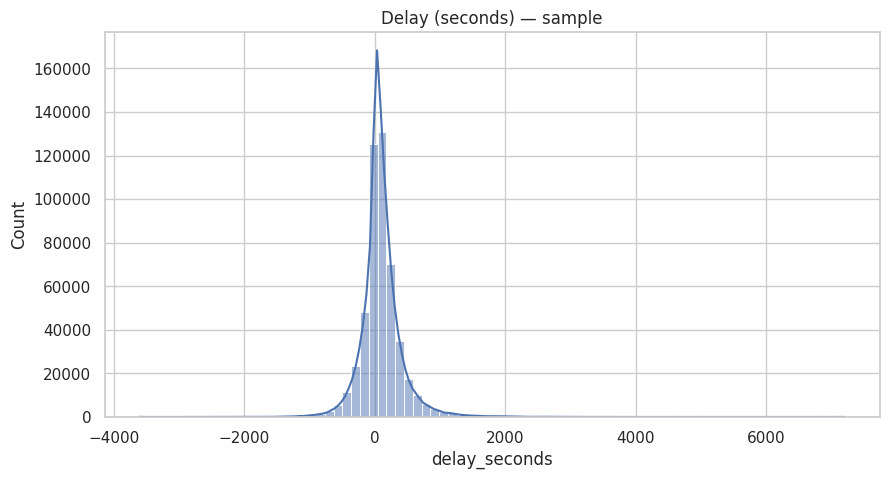

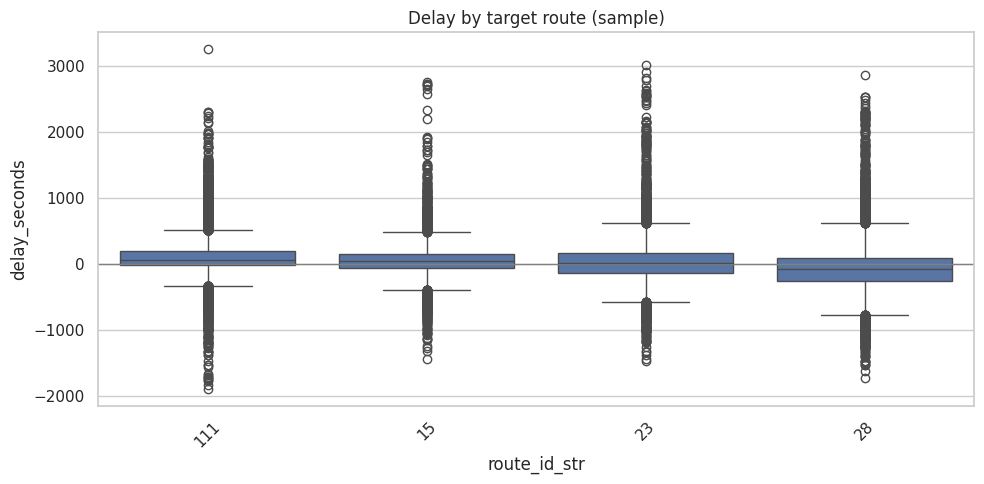

In [ ]:
if "delay_seconds" in df_sample.columns:
    d = df_sample["delay_seconds"].replace([np.inf, -np.inf], np.nan).dropna()
    d = d.clip(-3600, 7200)  # optional: clip extreme outliers for readability
    fig, ax = plt.subplots()
    sns.histplot(d, bins=80, kde=True, ax=ax)
    ax.set_title("Delay (seconds) — sample")
    plt.show()

    if len(df_target) > 0 and "delay_seconds" in df_target.columns:
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.boxplot(data=df_target, x="route_id_str", y="delay_seconds", ax=ax)
        ax.set_title("Delay by target route (sample)")
        ax.axhline(0, color="gray", lw=1)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
else:
    print("No delay_seconds yet — complete the derivation cell or merge delay from your pipeline.")

## 5. Correlation heatmap (meaningful numerics only)

Excluded identifier-like columns: ['half_trip_id', 'stop_id']
Dropped no-variance columns (would be NaN in Pearson): ['year', 'month']
Remaining for correlation: ['time_point_order', 'day', 'delay_seconds']


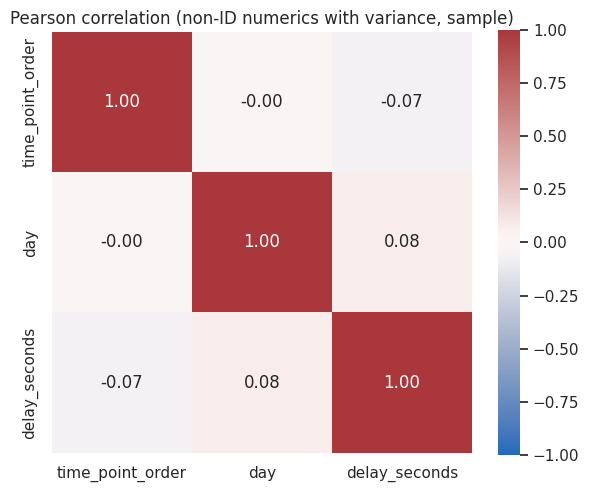

In [ ]:
num = df_sample.select_dtypes(include=[np.number]).copy()


def _is_identifier_column(name: str) -> bool:
    n = name.lower()
    return n.endswith("_id") or n == "id"


drop_id = [c for c in num.columns if _is_identifier_column(c)]
num = num.drop(columns=drop_id, errors="ignore")

low_var_cols = []
for c in num.columns:
    s = num[c]
    if s.notna().sum() == 0 or s.nunique(dropna=False) <= 1:
        low_var_cols.append(c)
    else:
        std = s.std(skipna=True)
        if std is None or (isinstance(std, (int, float)) and std == 0):
            low_var_cols.append(c)

num = num.drop(columns=low_var_cols, errors="ignore")

print("Excluded identifier-like columns:", drop_id)
print("Dropped no-variance columns (would be NaN in Pearson):", low_var_cols)
print("Remaining for correlation:", list(num.columns))

if num.shape[1] > 1:
    corr = num.corr(numeric_only=True)
    annot = num.shape[1] <= 10
    plt.figure(figsize=(max(6, num.shape[1] * 1.2), max(5, num.shape[1] * 1.0)))
    sns.heatmap(
        corr,
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        annot=annot,
        fmt=".2f" if annot else ".2f",
        square=True,
    )
    plt.title("Pearson correlation (non-ID numerics with variance, sample)")
    plt.tight_layout()
    plt.show()
elif num.shape[1] == 1:
    print("Only one numeric column after filtering:", list(num.columns))
    print("Join demographics / performance features for a multi-variable heatmap.")
else:
    print("No numeric columns left to correlate after filtering.")

##6. Chunked aggregates for full-file summaries

In [ ]:
# Scans the entire CSV (~26M rows) — can take many minutes; set True when you need full-file route counts
RUN_FULL_ROUTE_COUNTS = False

if not RUN_FULL_ROUTE_COUNTS:
    print("Skipping full-file scan. Set RUN_FULL_ROUTE_COUNTS = True in this cell to run.")
else:
    CHUNK = 2_000_000
    route_totals = {}

    for chunk in pd.read_csv(MBTA_FINAL, chunksize=CHUNK, usecols=["route_id"], low_memory=False):
        c = chunk["route_id"].astype(str).str.strip().value_counts()
        for r, v in c.items():
            route_totals[r] = route_totals.get(r, 0) + int(v)

    route_series = pd.Series(route_totals).sort_values(ascending=False)
    print("Top 20 routes by row count (full file, chunked):")
    display(route_series.head(20))

    for r in sorted(TARGET_ROUTE_IDS):
        print(f"Route {r}: {route_series.get(r, 0)} rows")

Skipping full-file scan. Set RUN_FULL_ROUTE_COUNTS = True in this cell to run.


## 7. MBTA 2024 system-wide passenger survey

In [ ]:
survey = pd.read_csv(SURVEY_2024, low_memory=False, encoding="utf-8-sig")
print(survey.shape)
survey.head()

(13866, 8)


,aggregation_level,service_mode,reporting_group,measure_group,measure,category,weighted_percent,ObjectId
0,Reporting Group,Bus,10,Alternative Modes,Alternative Mode,Drive or Ride in a Carpool,0.316855,1
1,Reporting Group,Bus,10,Alternative Modes,Alternative Mode,"Bike, Scooter, or Other Micromobility",0.000000,2
2,Reporting Group,Bus,10,Alternative Modes,Alternative Mode,Private Shuttle or Other Transit,0.000000,3
3,Reporting Group,Bus,10,Alternative Modes,Alternative Mode,Other,0.000000,4
4,Reporting Group,Bus,10,Alternative Modes,Used Alternative Mode,No,0.837547,5


In [ ]:
# Filter to bus-relevant rows for exploration
bus_mask = survey["service_mode"].astype(str).str.lower().eq("bus") if "service_mode" in survey.columns else pd.Series(True, index=survey.index)
survey_bus = survey.loc[bus_mask].copy()
print("Bus rows:", len(survey_bus))
survey_bus[["measure_group", "measure", "category", "weighted_percent"]].drop_duplicates().head(20)

Bus rows: 3915


,measure_group,measure,category,weighted_percent
0,Alternative Modes,Alternative Mode,Drive or Ride in a Carpool,0.316855
1,Alternative Modes,Alternative Mode,"Bike, Scooter, or Other Micromobility",0.000000
2,Alternative Modes,Alternative Mode,Private Shuttle or Other Transit,0.000000
3,Alternative Modes,Alternative Mode,Other,0.000000
4,Alternative Modes,Used Alternative Mode,No,0.837547
5,Alternative Modes,Used Alternative Mode,Yes,0.162458
6,Fares,Fare Product,Monthly Pass,0.359982
7,Fares,Fare Product,Pay-as-you-go,0.461622
8,Fares,Fare Product,7-day Pass,0.150117
9,Fares,Fare Product,Student Pass (M7),0.008994


## 7b. Survey — modes, reporting groups, trip mix

Each row is one **category** within a **measure**; `weighted_percent` is the estimated share (0–1). **Bus** `reporting_group` values include individual route IDs (e.g. `111`), corridor bundles (e.g. `28 & 29`), and aggregates like `All Bus`.

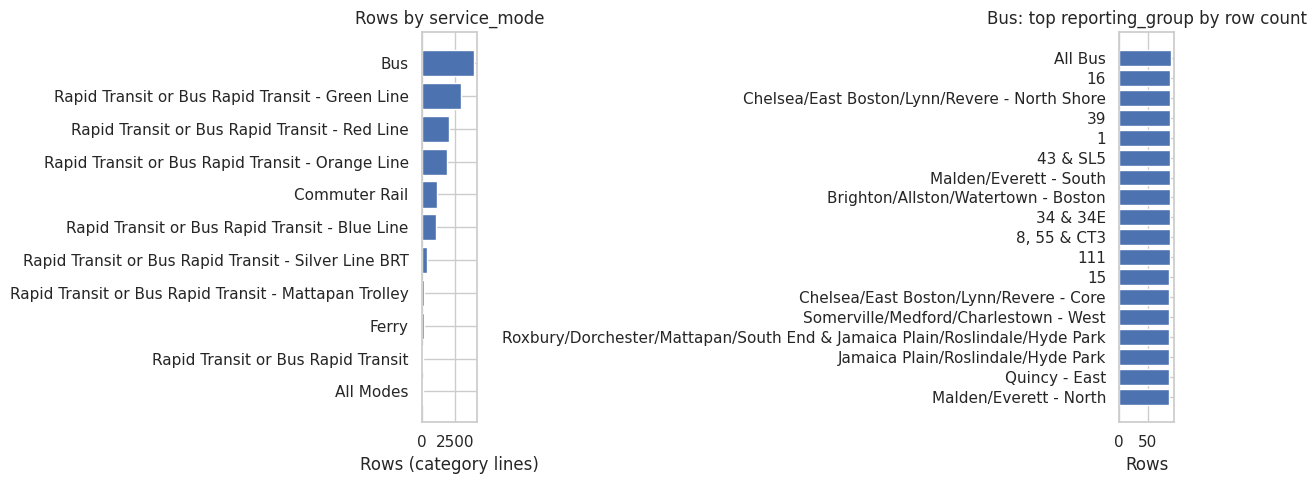

aggregation_level value_counts (top):


,count
aggregation_level,
Reporting Group,12864
Rapid Transit or Bus Rapid Transit Line,547
Service Mode,363
Systemwide,92


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mode_counts = survey["service_mode"].value_counts()
axes[0].barh(mode_counts.index[::-1], mode_counts.values[::-1])
axes[0].set_xlabel("Rows (category lines)")
axes[0].set_title("Rows by service_mode")

bus_rg = (
    survey.loc[survey["service_mode"].eq("Bus"), "reporting_group"]
    .astype(str)
    .value_counts()
    .head(18)
)
axes[1].barh(bus_rg.index[::-1], bus_rg.values[::-1])
axes[1].set_xlabel("Rows")
axes[1].set_title("Bus: top reporting_group by row count")

plt.tight_layout()
plt.show()

print("aggregation_level value_counts (top):")
display(survey["aggregation_level"].astype(str).value_counts().head(10))

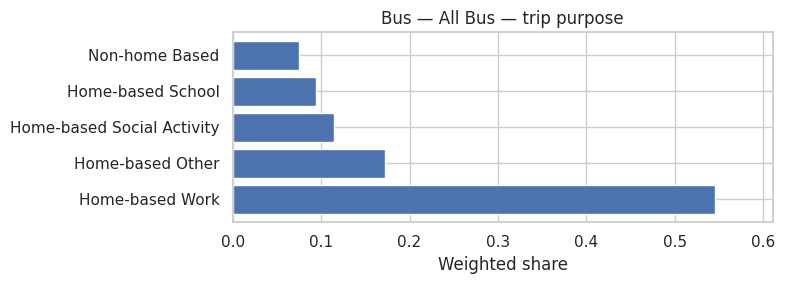

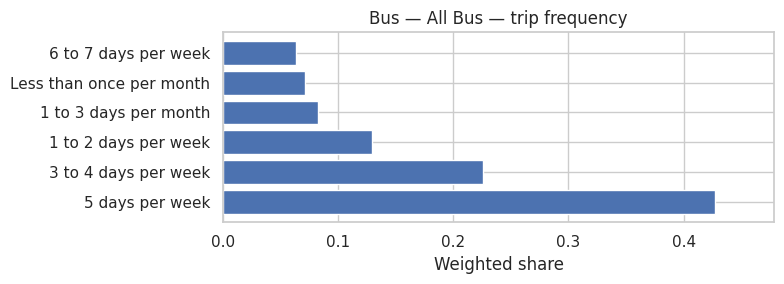

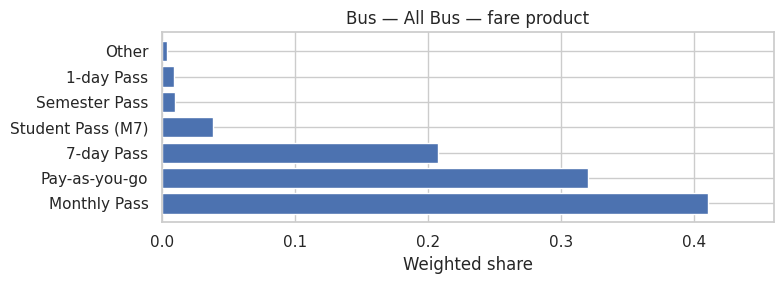

In [ ]:
def survey_slice(df, *, service_mode, reporting_group, measure_group, measure=None):
    m = (
        df["service_mode"].astype(str).eq(service_mode)
        & df["reporting_group"].astype(str).eq(reporting_group)
        & df["measure_group"].astype(str).eq(measure_group)
    )
    if measure is not None:
        m &= df["measure"].astype(str).eq(measure)
    out = df.loc[m, ["category", "weighted_percent"]].copy()
    out["weighted_percent"] = pd.to_numeric(out["weighted_percent"], errors="coerce")
    return out.sort_values("weighted_percent", ascending=False)


def plot_share_bars(slice_df, title):
    if slice_df.empty:
        print("No rows:", title)
        return
    fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(slice_df))))
    ax.barh(slice_df["category"], slice_df["weighted_percent"])
    ax.set_xlabel("Weighted share")
    ax.set_title(title)
    ax.set_xlim(0, max(slice_df["weighted_percent"].max() * 1.12, 0.01))
    plt.tight_layout()
    plt.show()


plot_share_bars(
    survey_slice(survey, service_mode="Bus", reporting_group="All Bus", measure_group="Trip Purpose and Frequency", measure="Trip Purpose"),
    "Bus — All Bus — trip purpose",
)
plot_share_bars(
    survey_slice(survey, service_mode="Bus", reporting_group="All Bus", measure_group="Trip Purpose and Frequency", measure="Frequency"),
    "Bus — All Bus — trip frequency",
)

freq = survey_slice(survey, service_mode="Bus", reporting_group="All Bus", measure_group="Fares", measure="Fare Product")
plot_share_bars(freq, "Bus — All Bus — fare product")

## 1. Temporal Delay Analysis

In [ ]:
# Ensure 'service_date' and 'actual' are datetime objects
# 'service_date' was already converted in a previous step, but 'actual' was not.
if df_sample['actual'].dtype == 'object':
    df_sample['actual'] = pd.to_datetime(df_sample['actual'], errors='coerce')

# Extract temporal features from the 'actual' departure time (or 'scheduled' if 'actual' is missing/invalid)
# Using 'actual' to get the hour of the actual event.
# We will use 'service_date' for day of week and month.

df_sample['hour_of_day'] = df_sample['actual'].dt.hour
df_sample['day_of_week'] = df_sample['service_date'].dt.day_name()
df_sample['month'] = df_sample['service_date'].dt.month_name()

print("Added 'hour_of_day', 'day_of_week', and 'month' columns to df_sample.")
display(df_sample[['service_date', 'actual', 'hour_of_day', 'day_of_week', 'month', 'delay_seconds']].head())

Added 'hour_of_day', 'day_of_week', and 'month' columns to df_sample.


,service_date,actual,hour_of_day,day_of_week,month,delay_seconds
0,2022-01-01,1900-01-01 06:24:56,6,Saturday,January,1196.0
1,2022-01-01,1900-01-01 06:27:46,6,Saturday,January,1126.0
2,2022-01-01,1900-01-01 06:32:16,6,Saturday,January,1216.0
3,2022-01-01,1900-01-01 06:35:03,6,Saturday,January,1203.0
4,2022-01-01,1900-01-01 06:38:10,6,Saturday,January,1150.0


### Average Delay by Hour of Day

/tmp/ipykernel_35652/84135115.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




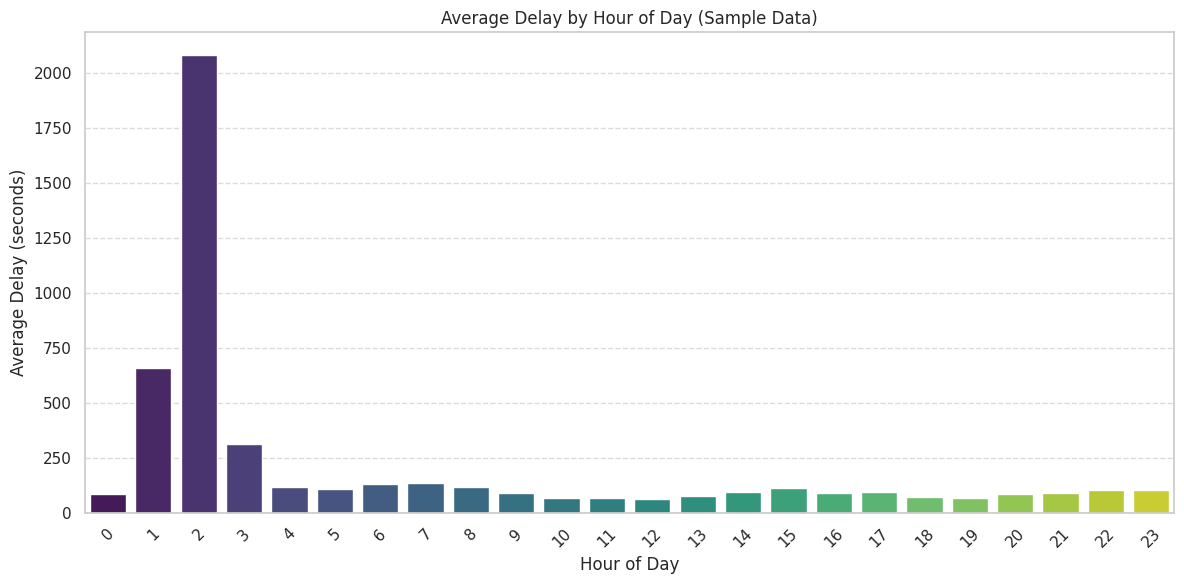

In [ ]:
avg_delay_by_hour = df_sample.groupby('hour_of_day')['delay_seconds'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='hour_of_day', y='delay_seconds', data=avg_delay_by_hour, palette='viridis')
plt.title('Average Delay by Hour of Day (Sample Data)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Delay (seconds)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Average Delay by Day of Week

/tmp/ipykernel_35652/429436814.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




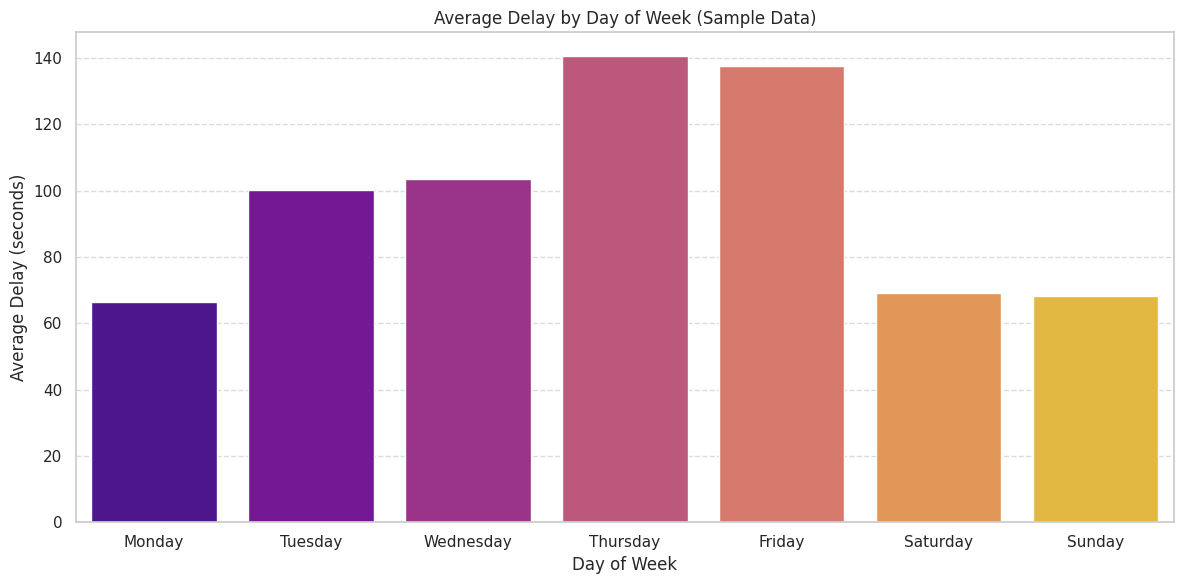

In [ ]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_delay_by_day = df_sample.groupby('day_of_week')['delay_seconds'].mean().reindex(day_order).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='day_of_week', y='delay_seconds', data=avg_delay_by_day, palette='plasma')
plt.title('Average Delay by Day of Week (Sample Data)')
plt.xlabel('Day of Week')
plt.ylabel('Average Delay (seconds)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 2. Geospatial Delay Analysis

In [ ]:
# Merge df_sample with df_stops_geo to get coordinates for each stop
# We'll merge on 'stop_id'. Ensure both are of the same type for merging.

df_sample['stop_id'] = df_sample['stop_id'].astype(str)
df_stops_geo['stop_id'] = df_stops_geo['stop_id'].astype(str)

df_geo_delays = pd.merge(df_sample, df_stops_geo[['stop_id', 'stop_lat', 'stop_lon']], on='stop_id', how='left')

# Calculate average delay per stop
avg_delay_per_stop = df_geo_delays.groupby(['stop_id', 'stop_lat', 'stop_lon', 'stop_name'])['delay_seconds'].mean().reset_index()

# Filter out any stops where coordinates might still be missing after the merge (shouldn't happen if df_stops_geo was cleaned correctly)
avg_delay_per_stop = avg_delay_per_stop.dropna(subset=['stop_lat', 'stop_lon'])

print(f"Number of unique stops with average delays and coordinates: {len(avg_delay_per_stop)}")
display(avg_delay_per_stop.head())

Number of unique stops with average delays and coordinates: 1050


,stop_id,stop_lat,stop_lon,stop_name,delay_seconds
0,10000,42.355692,-71.062911,tremont st opp temple pl,91.002381
1,10006,42.335814,-71.070135,albany st opp e newton st,301.084459
2,10008,42.339915,-71.064356,albany st opp randolph st,282.368243
3,10011,42.340162,-71.064227,albany st @ randolph st,189.226974
4,10016,42.499312,-71.162566,unknown,79.836207


### Geomap of Average Delays by Stop Location

In [ ]:
fig = px.scatter_mapbox(
    avg_delay_per_stop,
    lat="stop_lat",
    lon="stop_lon",
    hover_name="stop_name",
    hover_data=["stop_id", "delay_seconds"],
    color="delay_seconds", # Color points by average delay
    color_continuous_scale=px.colors.sequential.Viridis, # Use a color scale for delay
    size=abs(avg_delay_per_stop['delay_seconds']), # Size points by absolute delay for visibility (larger = more delay)
    zoom=9,
    height=600,
    title="Average Bus Delay (seconds) by Stop Location"
)
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

### Filtered Average Delay by Stop Location (excluding 'unknown' stop names)

In [ ]:
# Filter out rows where stop_name is 'unknown'
avg_delay_per_stop_filtered = avg_delay_per_stop[avg_delay_per_stop['stop_name'] != 'unknown'].copy()

print(f"Number of unique stops with average delays and coordinates (after filtering 'unknown' stop names): {len(avg_delay_per_stop_filtered)}")
display(avg_delay_per_stop_filtered.head())

Number of unique stops with average delays and coordinates (after filtering 'unknown' stop names): 414


,stop_id,stop_lat,stop_lon,stop_name,delay_seconds
0,10000,42.355692,-71.062911,tremont st opp temple pl,91.002381
1,10006,42.335814,-71.070135,albany st opp e newton st,301.084459
2,10008,42.339915,-71.064356,albany st opp randolph st,282.368243
3,10011,42.340162,-71.064227,albany st @ randolph st,189.226974
6,1026,42.348296,-71.153761,chestnut hill ave @ veronica smith ctr,94.756672


### Geomap of Average Delays by Stop Location (Filtered)

In [ ]:
import plotly.express as px

fig = px.scatter_mapbox(
    avg_delay_per_stop_filtered,
    lat="stop_lat",
    lon="stop_lon",
    hover_name="stop_name",
    hover_data=["stop_id", "delay_seconds"],
    color="delay_seconds", # Color points by average delay
    color_continuous_scale=px.colors.sequential.Viridis, # Use a color scale for delay
    size=abs(avg_delay_per_stop_filtered['delay_seconds']), # Size points by absolute delay for visibility (larger = more delay)
    zoom=9,
    height=600,
    title="Average Bus Delay (seconds) by Stop Location (Filtered)"
)
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

TARGET_ROUTE_IDS with exact Bus reporting_group: ['111', '15', '23']
Example bundled groups mentioning routes: ['28 & 29']


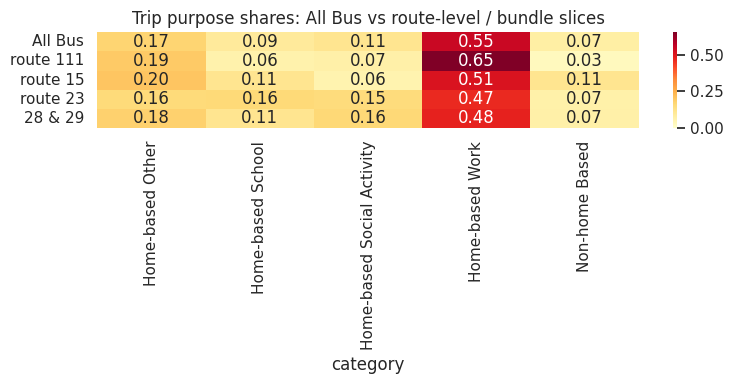

In [ ]:
bus_rg_set = set(survey.loc[survey["service_mode"].eq("Bus"), "reporting_group"].astype(str))
target_hits = sorted(TARGET_ROUTE_IDS & bus_rg_set)
bundles_for_targets = sorted(
    x for x in bus_rg_set if any(r in x.split() for r in TARGET_ROUTE_IDS) and ("&" in x or "," in x)
)
print("TARGET_ROUTE_IDS with exact Bus reporting_group:", target_hits)
print("Example bundled groups mentioning routes:", bundles_for_targets[:15])

all_bus_tp = survey_slice(
    survey, service_mode="Bus", reporting_group="All Bus", measure_group="Trip Purpose and Frequency", measure="Trip Purpose"
).set_index("category")["weighted_percent"]

compare = {"All Bus": all_bus_tp}
for rid in target_hits:
    sl = survey_slice(
        survey, service_mode="Bus", reporting_group=rid, measure_group="Trip Purpose and Frequency", measure="Trip Purpose"
    )
    if not sl.empty:
        compare[f"route {rid}"] = sl.set_index("category")["weighted_percent"]

if "28 & 29" in bus_rg_set:
    sl = survey_slice(
        survey, service_mode="Bus", reporting_group="28 & 29", measure_group="Trip Purpose and Frequency", measure="Trip Purpose"
    )
    if not sl.empty:
        compare["28 & 29"] = sl.set_index("category")["weighted_percent"]

trip_cmp = pd.DataFrame(compare).T
trip_cmp = trip_cmp.reindex(sorted(trip_cmp.columns), axis=1)
fig, ax = plt.subplots(figsize=(max(8, 0.45 * trip_cmp.shape[1]), 4))
sns.heatmap(trip_cmp, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax, vmin=0, vmax=trip_cmp.to_numpy().max())
ax.set_title("Trip purpose shares: All Bus vs route-level / bundle slices")
plt.tight_layout()
plt.show()

## 8. MBTA V3 API — route metadata

Requires `MBTA_API_KEY` (`.env` or shell). Fetches [route](https://api-v3.mbta.com/docs/swagger/index.html#/Route/ApiWeb_RouteController_index) records for `TARGET_ROUTE_IDS` so you can align **survey reporting groups** (route IDs / bundles) with **long names, descriptions, and mode** from the live API.

Docs: [MBTA V3 API](https://api-v3.mbta.com/docs/swagger/index.html)

In [ ]:
import requests

MBTA_BASE = "https://api-v3.mbta.com"


def mbta_get(path, params=None):
    headers = {"Authorization": f"Bearer {MBTA_API_KEY}", "Accept": "application/json"}
    r = requests.get(f"{MBTA_BASE}{path}", params=params or {}, headers=headers, timeout=45)
    r.raise_for_status()
    return r.json()


def routes_dataframe(route_ids):
    rows = []
    for rid in sorted(route_ids):
        js = mbta_get("/routes", params={"filter[id]": rid})
        for item in js.get("data", []):
            a = item.get("attributes") or {}
            rows.append(
                {
                    "id": item.get("id"),
                    "short_name": a.get("short_name"),
                    "long_name": a.get("long_name"),
                    "description": a.get("description"),
                    "type": a.get("type"),
                }
            )
    return pd.DataFrame(rows)


if not MBTA_API_KEY:
    print("Set MBTA_API_KEY to call the API.")
else:
    try:
        sm = mbta_get("/routes", params={"filter[type]": "3", "page[limit]": "5"})
        print("Sample bus routes (type 3):")
        for item in sm.get("data", [])[:5]:
            a = item.get("attributes", {})
            print(" ", a.get("short_name"), "—", a.get("long_name"))

        routes_api = routes_dataframe(TARGET_ROUTE_IDS)
        print("\nTARGET_ROUTE_IDS from API:")
        display(routes_api)

        rid_to_long = routes_api.set_index("id")["long_name"].to_dict()
        bus_rg_for_api = set(survey.loc[survey["service_mode"].eq("Bus"), "reporting_group"].astype(str))
        for rid in sorted(TARGET_ROUTE_IDS):
            long_name = rid_to_long.get(rid, "(not returned by API)")
            in_survey = rid in bus_rg_for_api
            print(f"  {rid}: survey Bus row? {in_survey} | API: {long_name}")
    except requests.HTTPError as e:
        print("HTTP error:", e, getattr(e.response, "text", "")[:400])

Sample bus routes (type 3):
  SL1 — Logan Airport Terminals - South Station
  SL2 — Design Center - South Station
  SL3 — Chelsea Station - South Station
  SL4 — Nubian Station - South Station
  SL5 — Nubian Station - Temple Place

TARGET_ROUTE_IDS from API:


,id,short_name,long_name,description,type
0,111,111,Woodlawn - Haymarket Station,Frequent Bus,3
1,15,15,Fields Corner Station - Ruggles Station,Frequent Bus,3
2,23,23,Ashmont Station - Ruggles Station via Washingt...,Frequent Bus,3
3,28,28,Mattapan Station - Ruggles Station,Frequent Bus,3


  111: survey Bus row? True | API: Woodlawn - Haymarket Station
  15: survey Bus row? True | API: Fields Corner Station - Ruggles Station
  23: survey Bus row? True | API: Ashmont Station - Ruggles Station via Washington Street
  28: survey Bus row? False | API: Mattapan Station - Ruggles Station


In [ ]:
print("\nInformation about routes_api DataFrame:")
routes_api.info()


Information about routes_api DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           4 non-null      object
 1   short_name   4 non-null      object
 2   long_name    4 non-null      object
 3   description  4 non-null      object
 4   type         4 non-null      int64 
dtypes: int64(1), object(4)
memory usage: 292.0+ bytes


## Quantifying the Reliability Gap (Primary Goal)

In [ ]:
# Calculate system-wide delay statistics from df_sample
system_wide_avg_delay = df_sample['delay_seconds'].mean()
system_wide_std_delay = df_sample['delay_seconds'].std()

print(f"System-wide Average Delay: {system_wide_avg_delay:.2f} seconds")
print(f"System-wide Delay Standard Deviation: {system_wide_std_delay:.2f} seconds")

# Calculate delay statistics for each target route from df_target
target_route_delay_stats = df_target.groupby('route_id_str')['delay_seconds'].agg(['mean', 'std']).reset_index()
target_route_delay_stats.columns = ['route_id_str', 'avg_delay_seconds', 'std_delay_seconds']

print("\nDelay Statistics for Target Routes:")
display(target_route_delay_stats)


System-wide Average Delay: 100.05 seconds
System-wide Delay Standard Deviation: 328.85 seconds

Delay Statistics for Target Routes:


,route_id_str,avg_delay_seconds,std_delay_seconds
0,111,111.936414,271.572515
1,15,48.683465,276.489745
2,23,30.097471,322.989894
3,28,-63.824682,364.514915


### Visualizing Delay Comparisons

/tmp/ipykernel_35652/1085016994.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='route_id_str', y='avg_delay_seconds', data=target_route_delay_stats.sort_values('avg_delay_seconds', ascending=False), ax=axes[0], palette='viridis')
/tmp/ipykernel_35652/1085016994.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='route_id_str', y='std_delay_seconds', data=target_route_delay_stats.sort_values('std_delay_seconds', ascending=False), ax=axes[1], palette='plasma')


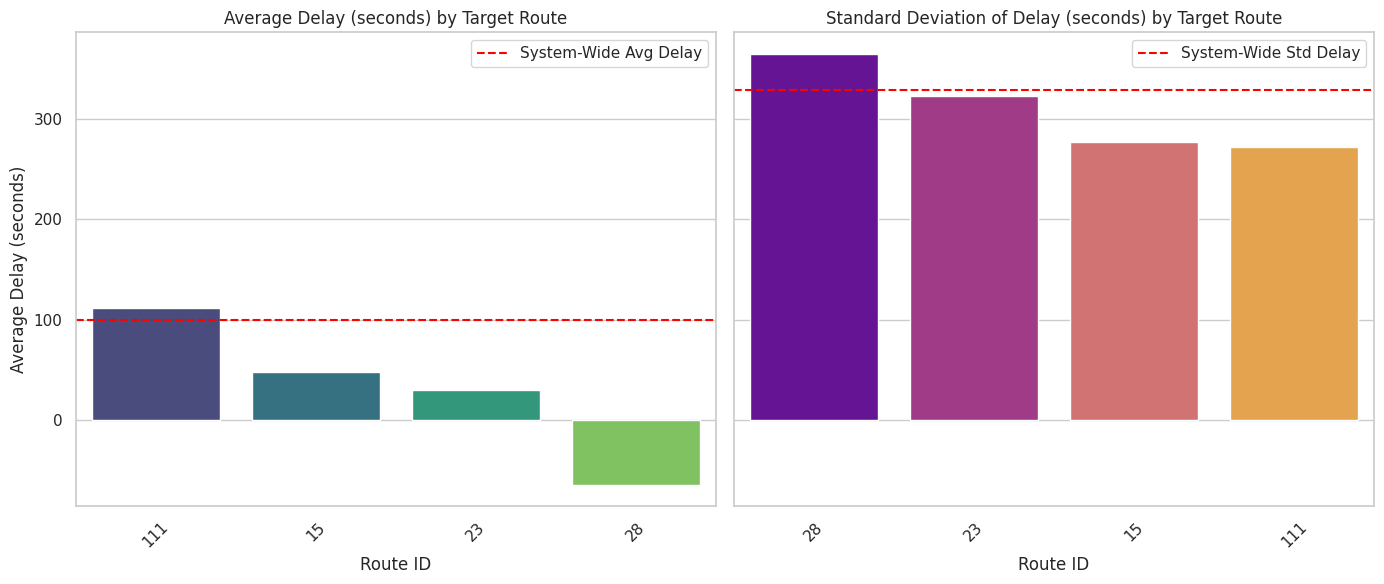

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Bar plot for Average Delay
sns.barplot(x='route_id_str', y='avg_delay_seconds', data=target_route_delay_stats.sort_values('avg_delay_seconds', ascending=False), ax=axes[0], palette='viridis')
axes[0].axhline(system_wide_avg_delay, color='red', linestyle='--', label='System-Wide Avg Delay')
axes[0].set_title('Average Delay (seconds) by Target Route')
axes[0].set_xlabel('Route ID')
axes[0].set_ylabel('Average Delay (seconds)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Bar plot for Standard Deviation of Delay
sns.barplot(x='route_id_str', y='std_delay_seconds', data=target_route_delay_stats.sort_values('std_delay_seconds', ascending=False), ax=axes[1], palette='plasma')
axes[1].axhline(system_wide_std_delay, color='red', linestyle='--', label='System-Wide Std Delay')
axes[1].set_title('Standard Deviation of Delay (seconds) by Target Route')
axes[1].set_xlabel('Route ID')
axes[1].set_ylabel('Standard Deviation of Delay (seconds)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()


## Data Cleaning and Normalization for `df_sample`

In [ ]:
# 1. Convert 'service_date' to datetime
df_sample['service_date'] = pd.to_datetime(df_sample['service_date'])
print(f"'service_date' dtype after conversion: {df_sample['service_date'].dtype}")

# 2. Convert 'half_trip_id' and 'time_point_order' to integer types
# Check for NaNs first, though 'missing' variable indicated none previously
if df_sample['half_trip_id'].isnull().any():
    print("Warning: 'half_trip_id' contains NaN values. Cannot convert directly to int.")
else:
    df_sample['half_trip_id'] = df_sample['half_trip_id'].astype(int)
    print(f"'half_trip_id' dtype after conversion: {df_sample['half_trip_id'].dtype}")

if df_sample['time_point_order'].isnull().any():
    print("Warning: 'time_point_order' contains NaN values. Cannot convert directly to int.")
else:
    df_sample['time_point_order'] = df_sample['time_point_order'].astype(int)
    print(f"'time_point_order' dtype after conversion: {df_sample['time_point_order'].dtype}")


'service_date' dtype after conversion: datetime64[ns]
'half_trip_id' dtype after conversion: int64
'time_point_order' dtype after conversion: int64


In [ ]:
# 3. Standardize categorical columns
categorical_cols = [
    'direction_id',
    'point_type',
    'standard_type',
    'neighborhood',
    'municipality',
    'stop_name'
]

for col in categorical_cols:
    if col in df_sample.columns:
        # Convert to string, strip whitespace, and convert to lowercase
        df_sample[col] = df_sample[col].astype(str).str.strip().str.lower()
        print(f"Standardized column: {col}")

print("\nData types after initial cleaning:")
df_sample.info()

Standardized column: direction_id
Standardized column: point_type
Standardized column: standard_type
Standardized column: neighborhood
Standardized column: municipality
Standardized column: stop_name

Data types after initial cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   service_date      500000 non-null  datetime64[ns]
 1   route_id          500000 non-null  object        
 2   direction_id      500000 non-null  object        
 3   half_trip_id      500000 non-null  int64         
 4   stop_id           500000 non-null  int64         
 5   time_point_id     500000 non-null  object        
 6   time_point_order  500000 non-null  int64         
 7   point_type        500000 non-null  object        
 8   standard_type     500000 non-null  object        
 9   scheduled         500000 non-null  object  

### Unique Values for Key Categorical Columns

In [ ]:
print("\nUnique values for 'direction_id':")
display(df_sample['direction_id'].value_counts())

print("\nUnique values for 'point_type':")
display(df_sample['point_type'].value_counts())

print("\nUnique values for 'standard_type':")
display(df_sample['standard_type'].value_counts())

print("\nUnique values for 'neighborhood' (top 20):")
display(df_sample['neighborhood'].value_counts().head(20))

print("\nUnique values for 'municipality':")
display(df_sample['municipality'].value_counts())



Unique values for 'direction_id':


,count
direction_id,
inbound,253163
outbound,246837



Unique values for 'point_type':


,count
point_type,
midpoint,361074
startpoint,70015
endpoint,68911



Unique values for 'standard_type':


,count
standard_type,
schedule,270247
headway,229753



Unique values for 'neighborhood' (top 20):


,count
neighborhood,
unknown,239824
roxbury,53557
dorchester,38300
jamaica plain,20992
downtown,13306
south boston,12790
fenway,11865
roslindale,11413
mattapan,11340



Unique values for 'municipality':


,count
municipality,
boston,260176
unknown,239824


## Inspecting `stops.txt` for Geographical Data

In [ ]:
STOPS_FILE = PROJECT_ROOT / "stops.txt"

if STOPS_FILE.exists():
    print(f"Loading stops data from: {STOPS_FILE}")
    df_stops = pd.read_csv(STOPS_FILE, low_memory=False)
    print("First 5 rows of stops.txt:")
    display(df_stops.head())
    print("\nInformation about stops.txt:")
    df_stops.info()
else:
    print(f"Error: stops.txt not found at {STOPS_FILE}. Please ensure the file is in the correct path.")

Loading stops data from: /content/drive/MyDrive/CS506 Project/stops.txt
First 5 rows of stops.txt:


,stop_id,stop_code,stop_name,stop_desc,platform_code,platform_name,stop_lat,stop_lon,zone_id,stop_address,stop_url,level_id,location_type,parent_station,wheelchair_boarding,municipality,on_street,at_street,vehicle_type
0,1,1.0,Washington St opp Ruggles St,NaN,NaN,NaN,42.330957,-71.082754,ExpressBus-Downtown,NaN,https://www.mbta.com/stops/1,NaN,0,NaN,1,Boston,Washington Street,Ruggles Street,3.0
1,10,10.0,Theo Glynn Way @ Newmarket Sq,NaN,NaN,NaN,42.330555,-71.068787,LocalBus,NaN,https://www.mbta.com/stops/10,NaN,0,NaN,1,Boston,Theodore Glynn Way,Newmarket Square,3.0
2,10000,10000.0,Tremont St opp Temple Pl,NaN,NaN,NaN,42.355692,-71.062911,LocalBus,NaN,https://www.mbta.com/stops/10000,NaN,0,NaN,1,Boston,Tremont Street,Temple Place,3.0
3,10003,10003.0,Albany St opp Randall St,NaN,NaN,NaN,42.331591,-71.076237,LocalBus,NaN,https://www.mbta.com/stops/10003,NaN,0,NaN,1,Boston,Albany Street,Randall Street,3.0
4,10005,10005.0,Albany St opp E Concord St,NaN,NaN,NaN,42.335017,-71.071280,LocalBus,NaN,https://www.mbta.com/stops/10005,NaN,0,NaN,1,Boston,Albany Street,NaN,3.0



Information about stops.txt:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10244 entries, 0 to 10243
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   stop_id              10244 non-null  object 
 1   stop_code            7089 non-null   float64
 2   stop_name            10244 non-null  object 
 3   stop_desc            3274 non-null   object 
 4   platform_code        359 non-null    object 
 5   platform_name        1084 non-null   object 
 6   stop_lat             9406 non-null   float64
 7   stop_lon             9406 non-null   float64
 8   zone_id              7630 non-null   object 
 9   stop_address         312 non-null    object 
 10  stop_url             7765 non-null   object 
 11  level_id             2647 non-null   object 
 12  location_type        10244 non-null  int64  
 13  parent_station       3077 non-null   object 
 14  wheelchair_boarding  10244 non-null  int64  
 15  munici

## Normalizing and Inspecting `df_stops`

In [ ]:
# 1. Standardize categorical columns
string_cols_to_normalize = ['stop_id', 'stop_name', 'municipality']

for col in string_cols_to_normalize:
    if col in df_stops.columns:
        df_stops[col] = df_stops[col].astype(str).str.strip().str.lower()
        print(f"Standardized column in df_stops: {col}")

print("\nData types after normalization:")
df_stops.info()

Standardized column in df_stops: stop_id
Standardized column in df_stops: stop_name
Standardized column in df_stops: municipality

Data types after normalization:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10244 entries, 0 to 10243
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   stop_id              10244 non-null  object 
 1   stop_code            7089 non-null   float64
 2   stop_name            10244 non-null  object 
 3   stop_desc            3274 non-null   object 
 4   platform_code        359 non-null    object 
 5   platform_name        1084 non-null   object 
 6   stop_lat             9406 non-null   float64
 7   stop_lon             9406 non-null   float64
 8   zone_id              7630 non-null   object 
 9   stop_address         312 non-null    object 
 10  stop_url             7765 non-null   object 
 11  level_id             2647 non-null   object 
 12  location_type        10

In [ ]:
# 2. Check for missing coordinates
print("\nMissing values in df_stops (coordinates and other key columns):")
display(df_stops[['stop_lat', 'stop_lon', 'stop_name', 'municipality']].isnull().sum())


Missing values in df_stops (coordinates and other key columns):


,0
stop_lat,838
stop_lon,838
stop_name,0
municipality,0


In [ ]:
# 3. Inspect unique values for key columns
print("\nUnique values for 'municipality' in df_stops:")
display(df_stops['municipality'].value_counts())

print("\nUnique values for 'location_type' in df_stops:")
display(df_stops['location_type'].value_counts())

print("\nUnique values for 'wheelchair_boarding' in df_stops:")
display(df_stops['wheelchair_boarding'].value_counts())


Unique values for 'municipality' in df_stops:


,count
municipality,
boston,3668
quincy,609
cambridge,532
newton,372
lynn,345
...,...
plymouth,2
hanson,2
whitman,2



Unique values for 'location_type' in df_stops:


,count
location_type,
0,7785
3,1861
2,323
1,275



Unique values for 'wheelchair_boarding' in df_stops:


,count
wheelchair_boarding,
1,9409
0,488
2,347


### Exploring Missing Latitude and Longitude Values in `df_stops`

In [ ]:
missing_coords = df_stops[df_stops['stop_lat'].isnull() | df_stops['stop_lon'].isnull()]
print(f"Number of records with missing 'stop_lat' or 'stop_lon': {len(missing_coords)}")
print("\nSample of stop_ids with missing coordinates:")
display(missing_coords['stop_id'].head(10))

print("\nSummary of missing coordinate columns:")
display(df_stops[['stop_lat', 'stop_lon']].isnull().sum())

Number of records with missing 'stop_lat' or 'stop_lon': 838

Sample of stop_ids with missing coordinates:


,stop_id
7634,node-123-platform
7635,node-124-platform
7636,node-301-platform
7637,node-872-lobby
7638,node-879-lobby
7639,node-879-platform
7640,node-880-lobby
7641,node-880-platform
7642,node-andrw-dotstairs-lobby
7643,node-andrw-farepaid



Summary of missing coordinate columns:


,0
stop_lat,838
stop_lon,838


### Detailed Analysis of Stops with Missing Coordinates

In [ ]:
print("Top 20 stop_ids with missing coordinates:")
display(missing_coords['stop_id'].value_counts().head(20))

print("\nTop 20 stop_names associated with missing coordinates:")
display(missing_coords['stop_name'].value_counts().head(20))

print("\nTop 20 municipalities associated with missing coordinates:")
display(missing_coords['municipality'].value_counts().head(20))

Top 20 stop_ids with missing coordinates:


,count
stop_id,
node-wtcst-wtctstairs-top,1
node-123-platform,1
node-124-platform,1
node-301-platform,1
node-872-lobby,1
node-879-lobby,1
node-404-platform,1
node-404-lobby,1
node-403-platform,1



Top 20 stop_names associated with missing coordinates:


,count
stop_name,
south station,82
downtown crossing,65
state,61
park street,57
back bay,50
courthouse,44
aquarium,41
haymarket,40
wollaston,34



Top 20 municipalities associated with missing coordinates:


,count
municipality,
boston,755
quincy,34
cambridge,25
somerville,24


### Filtering Data to focus on 'boston' municipality

In [ ]:
df_boston = df_sample[df_sample['municipality'].astype(str).str.lower() == 'boston'].copy()
print(f"Shape of df_boston (records with municipality 'boston'): {df_boston.shape}")
print("\nFirst 5 rows of df_boston:")
display(df_boston.head())

Shape of df_boston (records with municipality 'boston'): (260176, 19)

First 5 rows of df_boston:


,service_date,route_id,direction_id,half_trip_id,stop_id,time_point_id,time_point_order,point_type,standard_type,scheduled,actual,year,month,day,neighborhood,stop_name,municipality,route_id_str,delay_seconds
4,2022-01-01,01,inbound,54137355,79,hynes,5,midpoint,schedule,1900-01-01 06:19:00.000,1900-01-01 06:38:10.000,2022,1,1,fenway,massachusetts ave @ newbury st,boston,01,1150.0
5,2022-01-01,01,inbound,54137355,187,masta,6,midpoint,schedule,1900-01-01 06:21:00.000,1900-01-01 06:42:40.000,2022,1,1,roxbury,massachusetts ave @ massachusetts ave station,boston,01,1300.0
6,2022-01-01,01,inbound,54137355,59,Wasma,7,midpoint,schedule,1900-01-01 06:25:00.000,1900-01-01 06:45:39.000,2022,1,1,roxbury,massachusetts ave @ washington st,boston,01,1239.0
9,2022-01-01,01,inbound,54137355,62,Melwa,8,midpoint,schedule,1900-01-01 06:29:00.000,1900-01-01 06:49:47.000,2022,1,1,roxbury,washington st @ williams st,boston,01,1247.0
10,2022-01-01,01,inbound,54137355,64,dudly,9,endpoint,schedule,1900-01-01 06:30:00.000,1900-01-01 06:50:16.000,2022,1,1,roxbury,nubian,boston,01,1216.0


## Redoing Heatmap with Full Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Attempting to load the full dataset from: {MBTA_FINAL}")
print("This may take several minutes and consume significant memory.")

df_full = pd.read_csv(MBTA_FINAL, low_memory=False)
df_full["route_id_str"] = df_full["route_id"].astype(str).str.strip()

print(f"Full dataset loaded with shape: {df_full.shape}")

Attempting to load the full dataset from: /content/drive/MyDrive/CS506 Project/mbta_final.csv
This may take several minutes and consume significant memory.
Full dataset loaded with shape: (26238802, 18)


In [ ]:
print("Calculating delay_seconds for the full dataset...")

if {"scheduled", "actual"}.issubset(df_full.columns):
    sched_full = pd.to_datetime(df_full["scheduled"], errors="coerce")
    act_full = pd.to_datetime(df_full["actual"], errors="coerce")
    df_full["delay_seconds"] = (act_full - sched_full).dt.total_seconds()
    print("delay_seconds calculated.")
else:
    print("Scheduled/actual columns not found in df_full; cannot calculate delay_seconds.")

Calculating delay_seconds for the full dataset...
delay_seconds calculated.


Excluded identifier-like columns (full dataset): ['half_trip_id', 'stop_id']
Dropped no-variance columns (would be NaN in Pearson, full dataset): ['year']
Remaining for correlation (full dataset): ['time_point_order', 'month', 'day', 'delay_seconds']
Calculating correlation matrix for the full dataset. This may take some time.


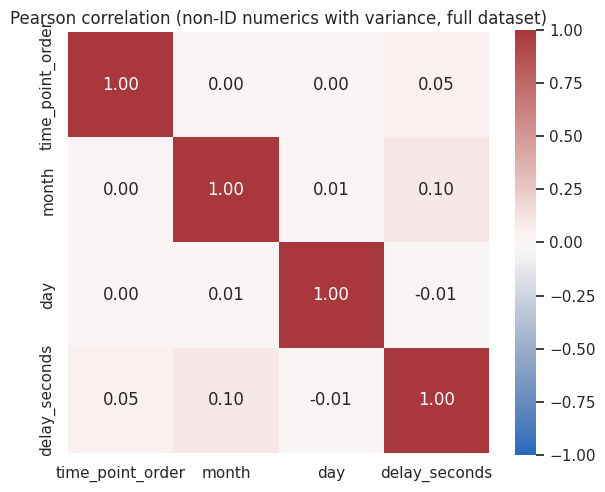

In [ ]:
num_full = df_full.select_dtypes(include=[np.number]).copy()

def _is_identifier_column(name: str) -> bool:
    n = name.lower()
    return n.endswith("_id") or n == "id"

drop_id_full = [c for c in num_full.columns if _is_identifier_column(c)]
num_full = num_full.drop(columns=drop_id_full, errors="ignore")

low_var_cols_full = []
for c in num_full.columns:
    s = num_full[c]
    if s.notna().sum() == 0 or s.nunique(dropna=False) <= 1:
        low_var_cols_full.append(c)
    else:
        std = s.std(skipna=True)
        if std is None or (isinstance(std, (int, float)) and std == 0):
            low_var_cols_full.append(c)

num_full = num_full.drop(columns=low_var_cols_full, errors="ignore")

print("Excluded identifier-like columns (full dataset):", drop_id_full)
print("Dropped no-variance columns (would be NaN in Pearson, full dataset):", low_var_cols_full)
print("Remaining for correlation (full dataset):", list(num_full.columns))

if num_full.shape[1] > 1:
    print("Calculating correlation matrix for the full dataset. This may take some time.")
    corr_full = num_full.corr(numeric_only=True)
    annot_full = num_full.shape[1] <= 10
    plt.figure(figsize=(max(6, num_full.shape[1] * 1.2), max(5, num_full.shape[1] * 1.0)))
    sns.heatmap(
        corr_full,
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        annot=annot_full,
        fmt=".2f" if annot_full else ".2f",
        square=True,
    )
    plt.title("Pearson correlation (non-ID numerics with variance, full dataset)")
    plt.tight_layout()
    plt.show()
elif num_full.shape[1] == 1:
    print("Only one numeric column after filtering (full dataset):", list(num_full.columns))
    print("Join demographics / performance features for a multi-variable heatmap.")
else:
    print("No numeric columns left to correlate after filtering (full dataset).")